<a href="https://colab.research.google.com/github/ZiqiLi379/STATS-302-Intro-to-ML/blob/main/STATS302_Week_5_Support_Vector_Machine_%26_ROC_Curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 5 - 9.6.2 Support Vector Machine & 9.6.3 ROC Curves
###STATS 302 Principle of Machine Learning
###Duke Kunshan University




In [1]:
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,roc_curve

from mlxtend.plotting import plot_decision_regions

import matplotlib.pyplot as plt
import seaborn as sns

# 9.6.2 Support Vector Machine

## Generating toy dataset

In [2]:
#setting the seed
X = np.random.normal(size = (200,2))
X[:100,] += 2
X[100:150,] -= 2
y = [0]*150 + [1]*50

data = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'y':y})
data.head()

,X1,X2,y
0,0.998671,1.601733,0
1,2.984630,2.063738,0
2,0.028206,1.850637,0
3,3.374953,1.880541,0
4,0.291552,2.200085,0


<Axes: xlabel='X1', ylabel='X2'>

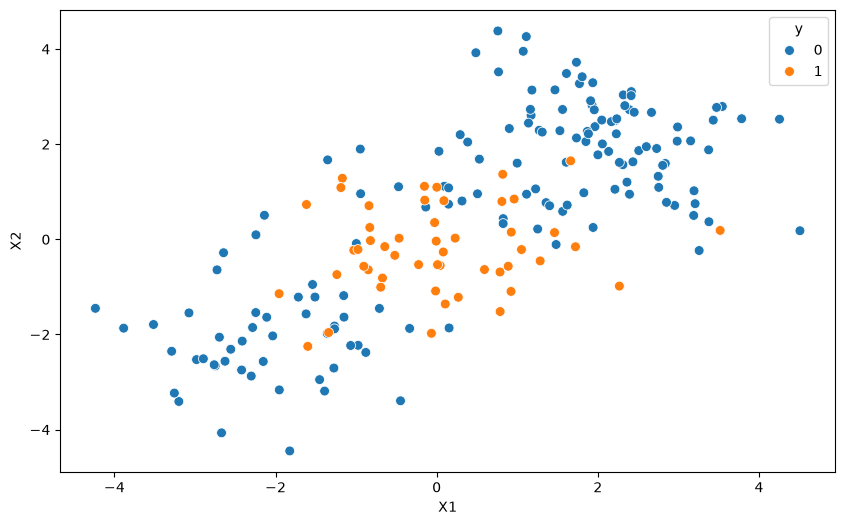

In [3]:
#plotting the data
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'X1',y = 'X2',hue = 'y',data = data,s = 50)

We can say that there is no possible linearly separation between the two classes

In [4]:
#splitting the data into train and test
X_train,X_test,y_train,y_test = train_test_split(data.drop('y',axis=1),data['y'],test_size = 0.5,random_state = 1)
print(X_train.shape,X_test.shape)

(100, 2) (100, 2)


## Fitting the model with radical kernal to training data
Gamma is used when we use the radical kernel. If you use linear or polynomial kernel then you do not need gamma only you need C hypermeter.

In [5]:
svm = SVC(kernel='rbf',gamma = 1,C = 1)
# gamma controls how far the influence of each training sample extends
# Large gamma -> small region, small gamma -> large region
svm.fit(X_train,y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Plotting the decision boundary

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'X2')

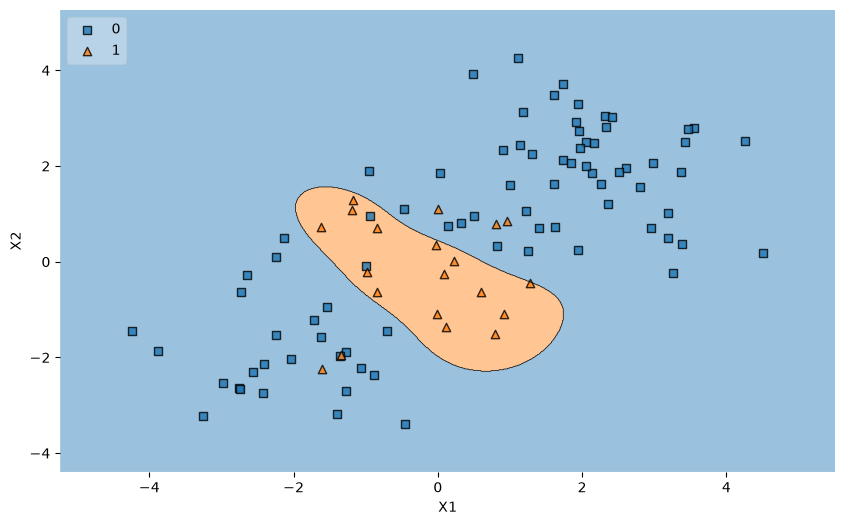

In [6]:
plt.figure(figsize = (10,6))
plot_decision_regions(np.array(X_train), np.array(y_train), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

In [7]:
print('Number of Support Vectors are ',svm.support_vectors_.shape[0])
print('Accuracy on training data is ',svm.score(X_train,y_train))

Number of Support Vectors are  58
Accuracy on training data is  0.93


## Choosing a high number of C

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Number of Support Vectors are  18
Accuracy on training data is  1.0


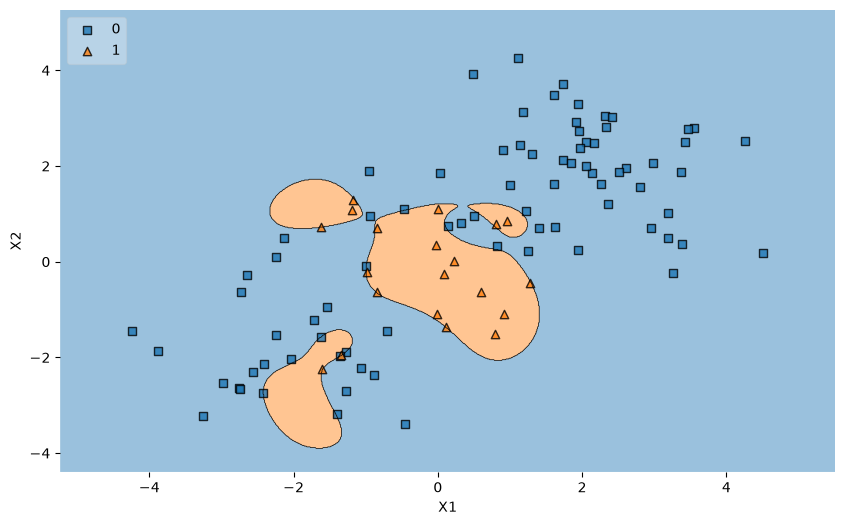

In [12]:
svm = SVC(kernel='rbf',gamma = 1,C = 10e5)
svm.fit(X_train,y_train)

### Plotting the decision boundary

plt.figure(figsize = (10,6))
plot_decision_regions(np.array(X_train), np.array(y_train), clf=svm, legend=2)

plt.xlabel('X1')
plt.ylabel('X2')

print('Number of Support Vectors are ',svm.support_vectors_.shape[0])
print('Accuracy on training data is ',svm.score(X_train,y_train))

## Choosing the optimal value of C and gamma using cross validation

In [13]:
params_dict = {'C':[0.1,1,10,100,1000],'gamma':[0.5,1,2,3,4]}
search = GridSearchCV(SVC(kernel = 'rbf'),params_dict,cv =10)
search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.5, 1, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherval

In [14]:
search.best_params_

{'C': 10, 'gamma': 0.5}

In [15]:
best_model = search.best_estimator_

## Performance of best_model on test data

In [16]:
test_preds = best_model.predict(X_test)
print('Test accuracy is ',accuracy_score(y_test,test_preds))
print('Confusion matrix is - ')
print(confusion_matrix(y_test,test_preds))

Test accuracy is  0.87
Confusion matrix is - 
[[69  1]
 [12 18]]


# 9.6.3 ROC curves

In [17]:
def plot_roc(cls,X,y,title):
    probs = cls.predict_proba(X)[:,1]  # Probability that the sample belong to class 1
    fpr, tpr, _ = roc_curve(y,probs)  # False Positive Rate (FPR): actual negatives incorrectly classified as positive
                                      # True Positive Rate (TPR): actual positives correctly identified
    auc = roc_auc_score(y,probs)    # Area Under the ROC Curve (AUC): 1.0 → perfect classifier

    plt.figure(figsize = (6,6))
    plt.plot(fpr,tpr,label="auc="+str(auc)[0:4],c = 'r')
    plt.plot([0,1],[0,1],alpha = 0.1,c = 'b')  # draws the diagonal: random classifier
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()


In [18]:
#because we need probability = True to get probs
best_model.probability = True
best_model.gamma = 0.5
best_model.fit(X_train,y_train)

D:\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


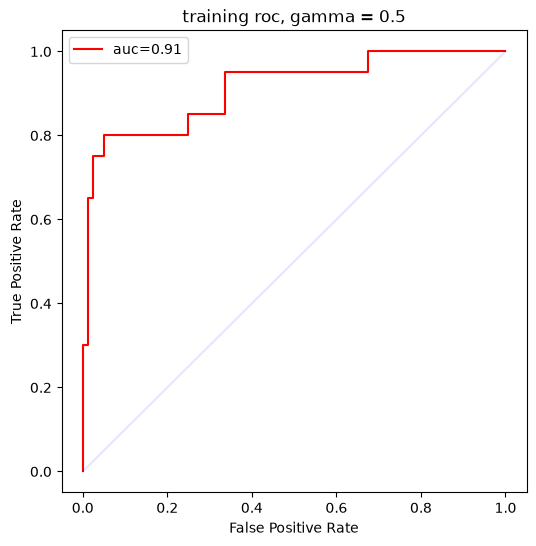

In [19]:
plot_roc(best_model,X_train,y_train,'training roc, gamma = 0.5')

D:\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


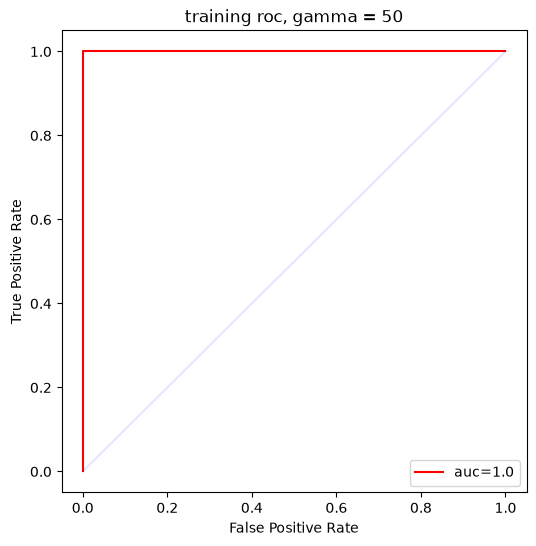

In [22]:
#roc curve if gamma is high
best_model.probability = True
best_model.gamma = 50
best_model.fit(X_train,y_train)

plot_roc(best_model,X_train,y_train,'training roc, gamma = 50')

woah...but wait, its training roc, not test roc :(

## Plotting the same on test data

In [23]:
def find_roc_terms(cls,X,y):
    probs = cls.predict_proba(X)[:,1]
    fpr,tpr,_ = roc_curve(y,probs)
    auc = roc_auc_score(y,probs)

    return fpr,tpr,auc

In [24]:
def plot_roc_test(cls,X_train,y_train,X_test,y_test):
    fpr,tpr,auc = find_roc_terms(cls,X_train,y_train)
    fpr_test,tpr_test,auc_test = find_roc_terms(cls,X_test,y_test)

    fig,(ax1,ax2) = plt.subplots(1,2,figsize = (12,6))
    ax1.plot(fpr,tpr,label="auc="+str(auc)[0:4],c = 'r')
    ax1.plot([0,1],[0,1],alpha = 0.1,c = 'b')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Train Roc')
    ax1.legend()

    ax2.plot(fpr_test,tpr_test,label="auc="+str(auc_test)[0:4],c = 'r')
    ax2.plot([0,1],[0,1],alpha = 0.1,c = 'b')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Test Roc')
    ax2.legend()


D:\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


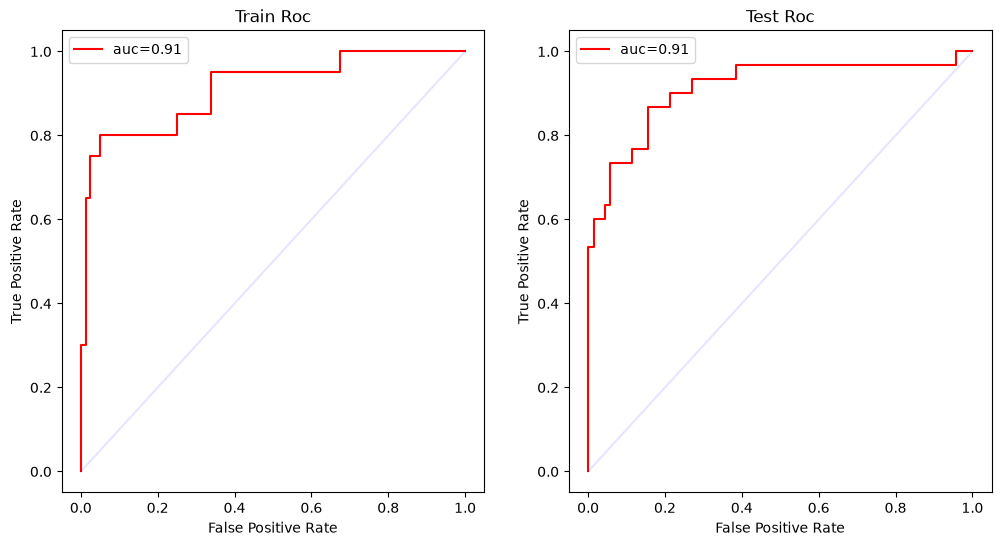

In [25]:
# for gamma = 0.5
best_model.gamma = 0.5
best_model.fit(X_train,y_train)

plot_roc_test(best_model,X_train,y_train,X_test,y_test)

D:\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


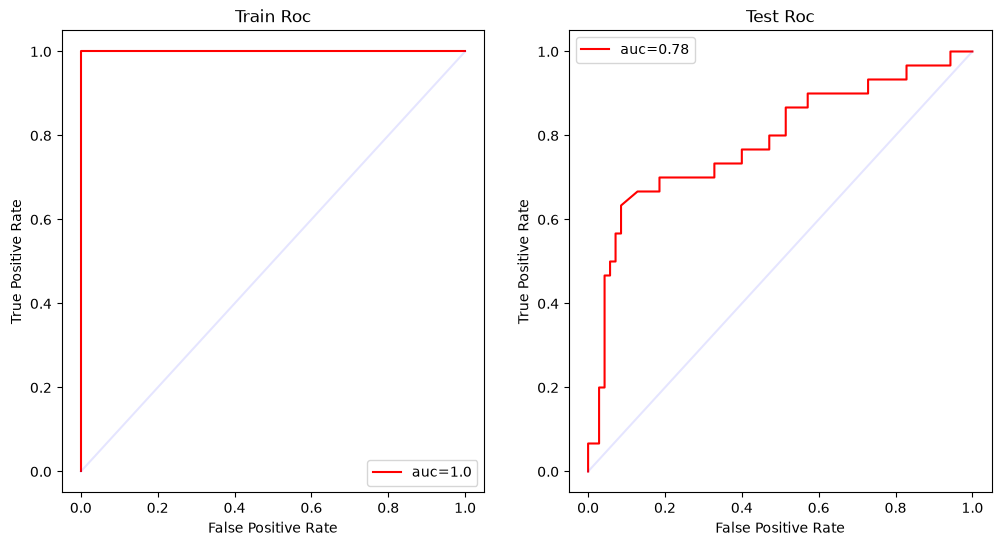

In [26]:
# for gamma = 50
best_model.gamma = 50
best_model.fit(X_train,y_train)

plot_roc_test(best_model,X_train,y_train,X_test,y_test)